In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fonctions

In [ ]:
# Paramètres
f = 0.005 # 5mm
lambda_0 = 600e-9 # 600nm
nt = 1.0
kt = (2 * np.pi * nt) / lambda_0
R_pupille = 0.004 # 4mm
NA = R_pupille/f

# Grilles
N = 250
x = np.linspace(-R_pupille, R_pupille, 2 * N)
y = np.linspace(-R_pupille, R_pupille, 2 * N)
z = np.linspace(-100e-6, 100e-6, 2 * N)
X, Y = np.meshgrid(x, y)
Rp = np.sqrt(X**2 + Y**2)

# Fonctions
def compute_E(E_t, theta, z):
  A = -(1j * f)/(lambda_0 * kt**2)
  cos_theta = np.cos(theta)
  kz = kt * cos_theta

  E_apres = np.zeros((len(x), len(y), len(z)), dtype = complex)

  for i in range(len(z)):
    exp = f_exp(kz, z[i])

    E_3D = (E_t * exp) / cos_theta
    E_apres[:, :, i] = np.fft.fftshift(np.fft.fft2(E_3D))

  return A * E_apres

def theta_field(X, Y, R, NA):
  r = np.sqrt(X**2 + Y**2)
  a = (r/R) * (NA/nt)
  a = np.clip(a, 0, 1)
  return np.arcsin(a)

def f_exp(kz, z):
  return np.exp(1j * kz * z)

def PlotAmplitude(field_phase):
  # Plot du champs après avec phase quadratique
  plt.figure()
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))
  mid = [s//2 for s in field_phase.shape]
  plt.suptitle('Coupes transversales')
  axes[0].imshow(field_phase[mid[0], :, :], cmap='viridis')
  axes[1].imshow(field_phase[:, mid[1], :], cmap='viridis')
  axes[2].imshow(field_phase[:, :, mid[2]], cmap='viridis')
  axes[0].set_title('Coupe YZ')
  axes[1].set_title('Coupe XZ')
  axes[2].set_title('Coupe XY')
  plt.tight_layout()

def Plotfaisceau(E_apres):
  field = np.abs(E_apres)
  mid = [s//2 for s in field.shape]
  upper_yz = np.zeros(len(z))
  lower_yz = np.zeros(len(z))

  for i in range(len(z)):
    idx_max = N
    idx_min = 0
    seuil = (1/2) * np.max(field[mid[0], :, i])

    for j in range(len(y)):
      if (field[mid[0], len(y) - j - 1, i] > seuil):
        idx_max = len(y) - j - 1
        break

    for j in range(len(y)):
      if (field[mid[0], j, i] > seuil):
        idx_min = j
        break

    upper_yz[i] = idx_max
    lower_yz[i] = idx_min

  return upper_yz, lower_yz

# Boucle sur la taille de la pupille

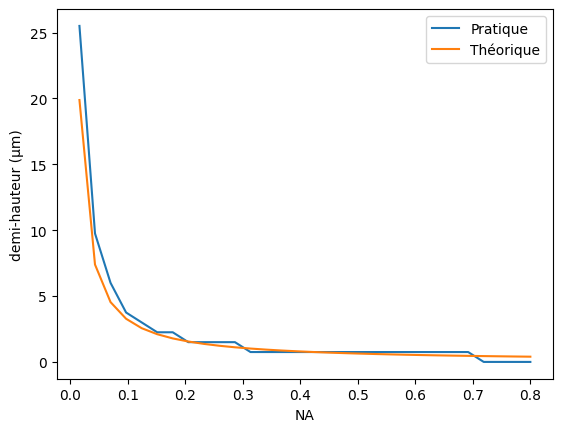

In [ ]:
R = np.linspace(0.00008, R_pupille, 30)
demi_hauteur = []
NA_list = []

pixel_size = (lambda_0 * f) / (2 * R_pupille)

for Ri in R:
  Et_gausse = np.exp(- 3 * (Rp/R_pupille)**2) # Champs gaussien avant la pupille
  Et_gausse[Rp > Ri] = 0 # Champs restreint à la pupile
  NA = Ri/f
  NA_list.append(NA)

  theta = theta_field(X, Y, Ri, NA) # Grille des theta

  E_gausse = compute_E(Et_gausse, theta, z) # Champs après sans phase quadratique

  # Plot du champs original
  plt.figure()
  plt.imshow(Et_gausse, cmap='viridis', origin='lower')
  plt.title(f'Champs original (Ri = {Ri:.4f} m)')
  plt.colorbar()
  plt.close()

  # Plot du champs après avec phase quadratique
  PlotAmplitude(np.abs(E_gausse))
  plt.close('all')

  mid = [s//2 for s in E_gausse.shape]
  upper_yz, lower_yz = Plotfaisceau(E_gausse)
  taille_pixels = upper_yz[mid[2]] - lower_yz[mid[2]]

  demi_hauteur.append(taille_pixels * pixel_size * 1e6)

plt.figure()
plt.plot(NA_list, demi_hauteur)
plt.plot(np.array(NA_list), (2 * np.sqrt(np.log(2)) * lambda_0 * 1e6)/(np.pi * np.array(NA_list)))
plt.legend(['Pratique','Théorique'])
plt.xlabel('NA')
plt.ylabel('demi-hauteur (µm)')
plt.show()